<a href="https://colab.research.google.com/github/nisha-s10/Deep-Learning-Lab-AFI524/blob/main/Experiment%208/Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### STEP 1 — Install and Import Libraries

In [ ]:
!pip install wandb
!pip install huggingface_hub

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import wandb
from torch.utils.data import random_split, DataLoader
from huggingface_hub import login
login()

### Step 2 — Initialize Weights & Biases

In [ ]:
wandb.init(
    project="Experiment-8-AE-VAE",
    mode="offline"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


### Step 3 — Dataset (Fashion-MNIST)
Requirement satisfied:
* Fashion-MNIST
* Normalize [0,1]
* 80/10/10 split

In [ ]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

total_size = len(dataset)

train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
remaining = total_size - train_size - val_size

train_dataset, val_dataset, _ = random_split(
    dataset,
    [train_size, val_size, remaining]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.27MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.53MB/s]


### Step 4 — Autoencoder Model


In [ ]:
class Autoencoder(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(784, 256),
            nn.ReLU(),

            nn.Linear(256, latent_dim)

        )

        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 784),
            nn.Sigmoid()

        )

    def forward(self, x):

        x = x.view(-1, 784)

        z = self.encoder(x)

        recon = self.decoder(z)

        return recon

### Step 5 — Train Autoencoder (MSE and BCE)

In [ ]:
def train_autoencoder(loss_function):

    latent_dim = 16

    model = Autoencoder(latent_dim).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    epochs = 10

    losses = []

    for epoch in range(epochs):

        total_loss = 0

        model.train()

        for images, _ in train_loader:

            images = images.to(device)

            images = images.view(-1, 784)

            optimizer.zero_grad()

            outputs = model(images)

            loss = loss_function(
                outputs,
                images
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        losses.append(epoch_loss)

        wandb.log({
            "model": "Autoencoder",
            "loss_function":
            loss_function.__class__.__name__,
            "epoch": epoch + 1,
            "train_loss": epoch_loss
        })

        print(
            "Epoch",
            epoch + 1,
            "Loss:",
            epoch_loss
        )

    return model, losses

### Train with BCE

In [ ]:
bce_model, bce_losses = train_autoencoder(
    nn.BCELoss()
)

Epoch 1 Loss: 0.34174007654190064
Epoch 2 Loss: 0.29550188795725507
Epoch 3 Loss: 0.2886036782264709
Epoch 4 Loss: 0.2849602568944295
Epoch 5 Loss: 0.2826996046702067
Epoch 6 Loss: 0.281132434686025
Epoch 7 Loss: 0.27994629367192586
Epoch 8 Loss: 0.27907882698376973
Epoch 9 Loss: 0.2784016482035319
Epoch 10 Loss: 0.2778083127339681


### Train with MSE

In [ ]:
mse_model, mse_losses = train_autoencoder(
    nn.MSELoss()
)

Epoch 1 Loss: 0.03503592416644096
Epoch 2 Loss: 0.01796931718289852
Epoch 3 Loss: 0.015638593894739945
Epoch 4 Loss: 0.014462687047819297
Epoch 5 Loss: 0.013728312306106091
Epoch 6 Loss: 0.013245033450424671
Epoch 7 Loss: 0.012882382571697236
Epoch 8 Loss: 0.01258950980504354
Epoch 9 Loss: 0.012355038938422998
Epoch 10 Loss: 0.012166690280040105


### Plot Loss Comparison

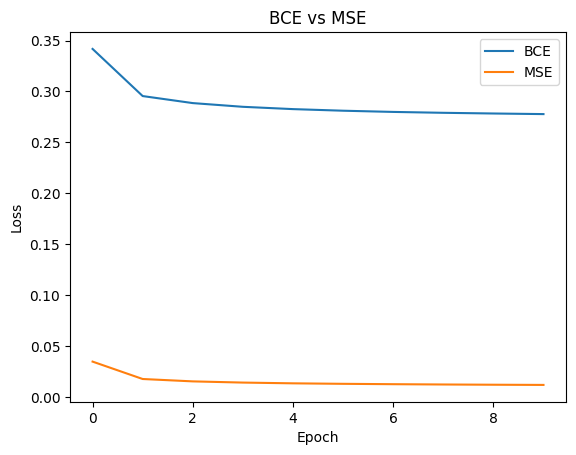

In [ ]:
plt.plot(bce_losses, label="BCE")

plt.plot(mse_losses, label="MSE")

plt.title("BCE vs MSE")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

### Step 6 — Variational Autoencoder (VAE)

In [ ]:
class VAE(nn.Module):

    def __init__(self, latent_dim):

        super().__init__()

        self.fc1 = nn.Linear(784, 256)

        self.fc_mu = nn.Linear(
            256,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            256,
            latent_dim
        )

        self.fc2 = nn.Linear(
            latent_dim,
            256
        )

        self.fc3 = nn.Linear(
            256,
            784
        )

    def encode(self, x):

        h = torch.relu(
            self.fc1(x)
        )

        mu = self.fc_mu(h)

        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(
            std
        )

        return mu + eps * std

    def decode(self, z):

        h = torch.relu(
            self.fc2(z)
        )

        return torch.sigmoid(
            self.fc3(h)
        )

    def forward(self, x):

        x = x.view(-1, 784)

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        recon = self.decode(z)

        return recon, mu, logvar

### VAE Loss

In [ ]:
def vae_loss(
    recon,
    x,
    mu,
    logvar
):

    BCE = nn.functional.binary_cross_entropy(
        recon,
        x,
        reduction="sum"
    )

    KL = -0.5 * torch.sum(
        1
        + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    return BCE + KL

### Train Autoencoder with Different Latent Dimensions

In [ ]:
latent_dims = [2, 8, 16, 32]

ae_models = {}
ae_losses = {}

epochs = 10

for latent_dim in latent_dims:

    print(
        "Training Autoencoder latent_dim =",
        latent_dim
    )

    model = Autoencoder(
        latent_dim
    ).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.to(device)

            images = images.view(
                -1,
                784
            )

            optimizer.zero_grad()

            recon = model(images)

            loss = nn.functional.mse_loss(
                recon,
                images
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = (
            total_loss
            / len(train_loader)
        )

        losses.append(epoch_loss)

        print(
            "Epoch",
            epoch + 1,
            epoch_loss
        )

    ae_models[
        latent_dim
    ] = model

    ae_losses[
        latent_dim
    ] = losses

Training Autoencoder latent_dim = 2
Epoch 1 0.04350066631038984
Epoch 2 0.03321537746985753
Epoch 3 0.03193071639537811
Epoch 4 0.03117855594555537
Epoch 5 0.030689804424842197
Epoch 6 0.03028739387790362
Epoch 7 0.029997802580396336
Epoch 8 0.029725615491469702
Epoch 9 0.029460909018913906
Epoch 10 0.02927782441675663
Training Autoencoder latent_dim = 8
Epoch 1 0.03347094787160555
Epoch 2 0.01926922353108724
Epoch 3 0.017706769458949567
Epoch 4 0.016814606475333373
Epoch 5 0.016294819109141826
Epoch 6 0.015907822839915754
Epoch 7 0.01564169527590275
Epoch 8 0.015406292436023553
Epoch 9 0.015224658119181791
Epoch 10 0.015066643220682938
Training Autoencoder latent_dim = 16
Epoch 1 0.0348205765436093
Epoch 2 0.01779706384986639
Epoch 3 0.015458002087970575
Epoch 4 0.014365432364245256
Epoch 5 0.013661326433221498
Epoch 6 0.0131548293530941
Epoch 7 0.012769255389769873
Epoch 8 0.012497318096458912
Epoch 9 0.012284741366902987
Epoch 10 0.01209534529596567
Training Autoencoder latent_dim =

### Step 7 — Train VAE with Latent Dimensions

In [ ]:
latent_dims = [2, 8, 16, 32]

trained_models = {}
all_losses = {}

for latent_dim in latent_dims:

    print("Training latent_dim:", latent_dim)

    vae = VAE(latent_dim).to(device)

    optimizer = optim.Adam(
        vae.parameters(),
        lr=0.001
    )

    losses = []

    for epoch in range(10):

        total_loss = 0

        for images, _ in train_loader:

            images = images.to(device)

            images = images.view(-1, 784)

            optimizer.zero_grad()

            recon, mu, logvar = vae(images)

            loss = vae_loss(
                recon,
                images,
                mu,
                logvar
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        losses.append(epoch_loss)

        wandb.log({
            "model": "VAE",
            "latent_dim": latent_dim,
            "epoch": epoch + 1,
            "train_loss": epoch_loss
        })

        print("Epoch", epoch + 1, epoch_loss)

    trained_models[latent_dim] = vae
    all_losses[latent_dim] = losses

Training latent_dim: 2
Epoch 1 39005.80744791667
Epoch 2 35116.01729166666
Epoch 3 34720.00756770834
Epoch 4 34498.45105729167
Epoch 5 34323.667177083335
Epoch 6 34211.620328125
Epoch 7 34128.137604166666
Epoch 8 34054.20041666667
Epoch 9 33984.812421875
Epoch 10 33920.17839583333
Training latent_dim: 8
Epoch 1 37322.825203125
Epoch 2 32806.61069270833
Epoch 3 32231.054932291667
Epoch 4 31954.02990625
Epoch 5 31753.552510416666
Epoch 6 31624.696265625
Epoch 7 31527.600786458333
Epoch 8 31448.763541666667
Epoch 9 31381.18996875
Epoch 10 31325.566442708332
Training latent_dim: 16
Epoch 1 37823.5696875
Epoch 2 33308.84749479167
Epoch 3 32557.048942708334
Epoch 4 32157.285171875
Epoch 5 31904.05003125
Epoch 6 31734.332453125
Epoch 7 31607.712640625
Epoch 8 31505.218890625
Epoch 9 31426.730958333334
Epoch 10 31362.090828125
Training latent_dim: 32
Epoch 1 38536.258625
Epoch 2 33937.340734375
Epoch 3 32917.833671875
Epoch 4 32373.777072916666
Epoch 5 32028.302583333334
Epoch 6 31796.24453125

### Reconstruction Comparison

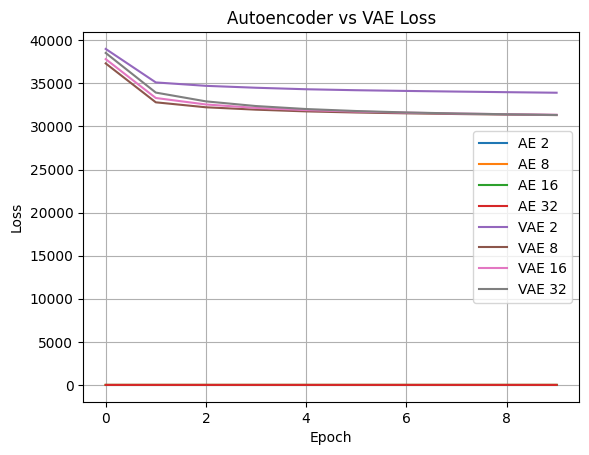

In [ ]:
plt.figure()

for dim in ae_losses:

    plt.plot(
        ae_losses[dim],
        label=f"AE {dim}"
    )

for dim in all_losses:

    plt.plot(
        all_losses[dim],
        label=f"VAE {dim}"
    )

plt.title(
    "Autoencoder vs VAE Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### Step 8 — Reconstruction Visualization

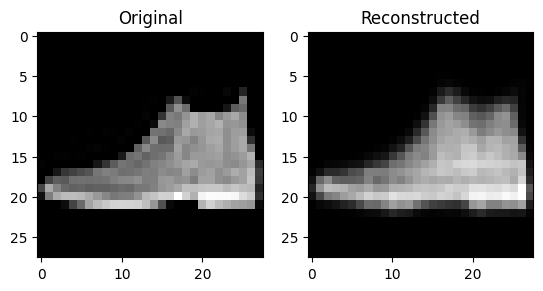

In [ ]:
images, _ = next(iter(test_loader))

images = images.to(device)

vae = trained_models[16]

vae.eval()

with torch.no_grad():

    recon, _, _ = vae(
        images.view(-1, 784)
    )

plt.subplot(1,2,1)

plt.imshow(
    images[0].cpu().squeeze(),
    cmap="gray"
)

plt.title("Original")

plt.subplot(1,2,2)

plt.imshow(
    recon[0].cpu().view(28,28),
    cmap="gray"
)

plt.title("Reconstructed")

plt.show()

### Step 9 — Latent Space Visualization (2D)

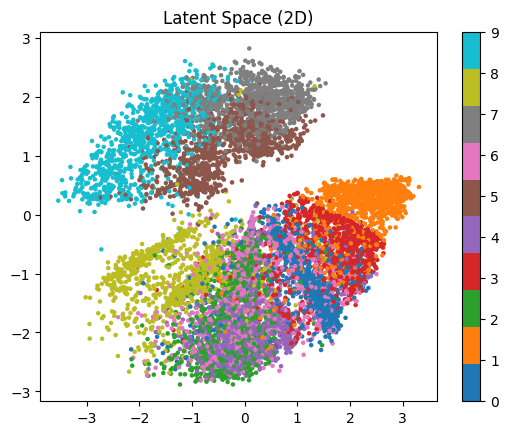

In [ ]:
vae = trained_models[2]

z_list = []
labels_list = []

for images, labels in test_loader:

    images = images.to(device)

    images = images.view(-1, 784)

    with torch.no_grad():

        mu, _ = vae.encode(images)

    z_list.append(mu.cpu())

    labels_list.append(labels)

z = torch.cat(z_list)

labels = torch.cat(labels_list)

plt.scatter(
    z[:,0],
    z[:,1],
    c=labels,
    cmap="tab10",
    s=5
)

plt.colorbar()

plt.title(
    "Latent Space (2D)"
)

plt.show()

### Step 10 — Latent Interpolation

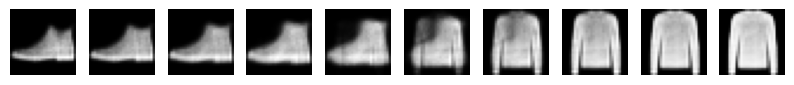

In [ ]:
vae = trained_models[16]

images, _ = next(iter(test_loader))

img1 = images[0].unsqueeze(0).to(device)

img2 = images[1].unsqueeze(0).to(device)

with torch.no_grad():

    z1, _ = vae.encode(
        img1.view(-1, 784)
    )

    z2, _ = vae.encode(
        img2.view(-1, 784)
    )

alphas = torch.linspace(0, 1, 10)

plt.figure(figsize=(10,2))

for i, alpha in enumerate(alphas):

    z = (
        (1 - alpha) * z1
        + alpha * z2
    )

    with torch.no_grad():

        img = vae.decode(z)

    plt.subplot(
        1,
        10,
        i + 1
    )

    plt.imshow(
        img.cpu().view(28,28),
        cmap="gray"
    )

    plt.axis("off")

plt.show()

### Step 11 — Optimizer Comparison

In [ ]:
models = {
    "Autoencoder": Autoencoder,
    "VAE": VAE
}

optimizers = {
    "SGD": optim.SGD,
    "RMSprop": optim.RMSprop,
    "Adam": optim.Adam
}

epochs = 5
latent_dim = 16

for model_name, model_class in models.items():

    for opt_name, opt_class in optimizers.items():

        print(
            f"\nTraining {model_name} with {opt_name}"
        )

        model = model_class(
            latent_dim
        ).to(device)

        optimizer = opt_class(
            model.parameters(),
            lr=0.0001
        )

        for epoch in range(epochs):

            total_loss = 0

            for images, _ in train_loader:

                images = images.to(device)

                images = images.view(
                    -1,
                    784
                )

                optimizer.zero_grad()

                # Handle both models correctly

                if model_name == "VAE":

                    recon, mu, logvar = model(images)

                    loss = vae_loss(
                        recon,
                        images,
                        mu,
                        logvar
                    )

                else:

                    recon = model(images)

                    loss = nn.functional.mse_loss(
                        recon,
                        images
                    )

                loss.backward()

                optimizer.step()

                total_loss += loss.item()

            epoch_loss = (
                total_loss
                / len(train_loader)
            )

            wandb.log({
                "model": model_name,
                "optimizer": opt_name,
                "epoch": epoch + 1,
                "train_loss": epoch_loss
            })

            print(
                model_name,
                opt_name,
                "Epoch",
                epoch + 1,
                "Loss:",
                epoch_loss
            )


Training Autoencoder with SGD
Autoencoder SGD Epoch 1 Loss: 0.17037431387106577
Autoencoder SGD Epoch 2 Loss: 0.17036949916680655
Autoencoder SGD Epoch 3 Loss: 0.17036468776067099
Autoencoder SGD Epoch 4 Loss: 0.17035987706979117
Autoencoder SGD Epoch 5 Loss: 0.17035506808757783

Training Autoencoder with RMSprop
Autoencoder RMSprop Epoch 1 Loss: 0.05680169093608856
Autoencoder RMSprop Epoch 2 Loss: 0.03328959695994854
Autoencoder RMSprop Epoch 3 Loss: 0.0273867140909036
Autoencoder RMSprop Epoch 4 Loss: 0.024867559229334195
Autoencoder RMSprop Epoch 5 Loss: 0.023223904197414717

Training Autoencoder with Adam
Autoencoder Adam Epoch 1 Loss: 0.07613940142591795
Autoencoder Adam Epoch 2 Loss: 0.03603674774368604
Autoencoder Adam Epoch 3 Loss: 0.027629789476593336
Autoencoder Adam Epoch 4 Loss: 0.02429255194465319
Autoencoder Adam Epoch 5 Loss: 0.022263386875391006

Training VAE with SGD
VAE SGD Epoch 1 Loss: 45045.588541666664
VAE SGD Epoch 2 Loss: 43312.8461875
VAE SGD Epoch 3 Loss: 44

In [ ]:
from huggingface_hub import upload_file
from huggingface_hub import create_repo
import torch

# Create repository (runs once)
create_repo(
    repo_id="nishas3/experiment-8",
    repo_type="model",
    exist_ok=True
)

# Save all models
for dim in ae_models:

    torch.save(
        ae_models[dim].state_dict(),
        f"autoencoder_latent{dim}.pth"
    )

for dim in trained_models:

    torch.save(
        trained_models[dim].state_dict(),
        f"vae_latent{dim}.pth"
    )

print("Models saved successfully")

# Upload Autoencoder models
for dim in ae_models:

    upload_file(
        path_or_fileobj=f"autoencoder_latent{dim}.pth",
        path_in_repo=f"autoencoder_latent{dim}.pth",
        repo_id="nishas3/experiment-8",
        repo_type="model"
    )

# Upload VAE models
for dim in trained_models:

    upload_file(
        path_or_fileobj=f"vae_latent{dim}.pth",
        path_in_repo=f"vae_latent{dim}.pth",
        repo_id="nishas3/experiment-8",
        repo_type="model"
    )

print("Models uploaded to Hugging Face")

Models saved successfully


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Models uploaded to Hugging Face
